Choose input method:
1. Manual DNA input
2. Upload FASTA file
Enter 1 or 2: 2


Saving sample.fasta to sample.fasta

DNA: ATGCGTACGTTAGCGTACGATCGTAGCTAGCTAGGCTAGCTAGCTAGCTAGCGTACGTAG...
Emotions sample: ['Calm', 'Aggressive', 'Happy', 'Sad', 'Happy', 'Aggressive', 'Calm', 'Sad', 'Happy', 'Aggressive', 'Aggressive', 'Calm', 'Happy', 'Sad', 'Happy', 'Aggressive', 'Calm', 'Sad', 'Happy', 'Calm']


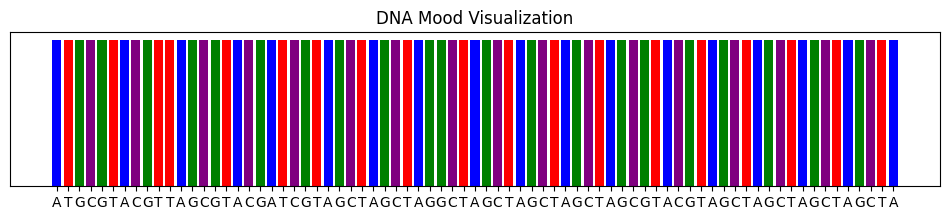

Playing DNA-based song...


File saved as dna_song.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Mood Score: 308.35
Overall Mood: Balanced / Happy


In [3]:
# COMPLETE DNA MOOD + SONG GENERATOR (COLAB - SINGLE CELL)

# Install required package (only needed first time)
!pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from google.colab import files
from scipy.io.wavfile import write

# ------------------------------
# DNA → Emotion + Music Mapping
# ------------------------------
mapping = {
    'A': {'color': 'blue', 'freq': 261, 'emotion': 'Calm'},
    'T': {'color': 'red', 'freq': 294, 'emotion': 'Aggressive'},
    'G': {'color': 'green', 'freq': 329, 'emotion': 'Happy'},
    'C': {'color': 'purple', 'freq': 349, 'emotion': 'Sad'}
}

# ------------------------------
# Input Method
# ------------------------------
print("Choose input method:")
print("1. Manual DNA input")
print("2. Upload FASTA file")

choice = input("Enter 1 or 2: ").strip()

dna = ""

if choice == "1":
    dna = input("Enter DNA sequence (A/T/G/C): ").upper().strip()

elif choice == "2":
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    with open(file_name, 'r') as f:
        lines = f.readlines()
        dna = "".join([line.strip() for line in lines if not line.startswith(">")]).upper()

else:
    raise ValueError("Invalid choice")

# ------------------------------
# Validation
# ------------------------------
if len(dna) == 0:
    raise ValueError("Empty DNA sequence")

for base in dna:
    if base not in mapping:
        raise ValueError("Invalid DNA sequence: only A, T, G, C allowed")

# ------------------------------
# Processing
# ------------------------------
colors = []
frequencies = []
emotions = []

for base in dna:
    colors.append(mapping[base]['color'])
    frequencies.append(mapping[base]['freq'])
    emotions.append(mapping[base]['emotion'])

print("\nDNA:", dna[:60] + ("..." if len(dna) > 60 else ""))
print("Emotions sample:", emotions[:20])

# ------------------------------
# Visualization
# ------------------------------
plt.figure(figsize=(12,2))
for i, color in enumerate(colors):
    plt.bar(i, 1, color=color)

plt.title("DNA Mood Visualization")
plt.xticks(range(len(dna)), list(dna))
plt.yticks([])
plt.show()

# ------------------------------
# Song Generator (20 seconds)
# ------------------------------
sample_rate = 44100

note_map = {
    'A': 261,
    'T': 294,
    'G': 329,
    'C': 349
}

def generate_wave(freq, duration, style):
    t = np.linspace(0, duration, int(sample_rate * duration), False)

    if style == "sine":
        wave = np.sin(2 * np.pi * freq * t)
    elif style == "square":
        wave = np.sign(np.sin(2 * np.pi * freq * t))
    else:
        wave = 2 * np.arcsin(np.sin(2 * np.pi * freq * t)) / np.pi

    envelope = np.linspace(0, 1, len(t))
    return wave * envelope

audio_parts = []
total_time = 0
styles = ["sine", "triangle", "square"]

i = 0
while total_time < 20:
    base = dna[i % len(dna)]
    freq = note_map[base]
    style = styles[i % len(styles)]

    duration = float(np.random.choice([0.2, 0.3, 0.4]))

    tone = generate_wave(freq, duration, style)

    beat = 0.2 * np.sin(2 * np.pi * 80 * np.linspace(0, duration, int(sample_rate * duration)))

    combined = tone + beat

    audio_parts.append(combined)
    audio_parts.append(np.zeros(int(sample_rate * 0.05)))

    total_time += duration + 0.05
    i += 1

audio = np.concatenate(audio_parts)

# ------------------------------
# Play Audio
# ------------------------------
print("Playing DNA-based song...")
display(Audio(audio, rate=sample_rate))

# ------------------------------
# Save Audio File
# ------------------------------
audio_norm = audio / np.max(np.abs(audio))
audio_int16 = np.int16(audio_norm * 32767)

write("dna_song.wav", sample_rate, audio_int16)

print("File saved as dna_song.wav")
files.download("dna_song.wav")

# ------------------------------
# Mood Score
# ------------------------------
mood_score = sum(frequencies) / len(frequencies)

print("\nMood Score:", round(mood_score, 2))

if mood_score < 300:
    print("Overall Mood: Calm / Sad")
elif mood_score < 320:
    print("Overall Mood: Balanced / Happy")
else:
    print("Overall Mood: Intense / Aggressive")